# The Linear Encoder Problem in Circuit Tracing

## Why we need Spline-CLT

Anthropic's [circuit tracing](https://transformer-circuits.pub/2025/attribution-graphs/methods.html) pipeline decomposes transformer MLP layers using **transcoders**. These transcoders use a **linear encoder** followed by an activation function (JumpReLU or ReLU) to extract sparse, interpretable features from the residual stream:

$$a^l = \sigma(W_{\text{enc}}^l \cdot x^l + b_{\text{enc}}^l)$$

This linear encoder assumes that **feature boundaries are linear hyperplanes** in activation space. But what if some features are defined by nonlinear activation patterns?

In this notebook we use the **published Qwen3-0.6B transcoders** from the [circuit-tracer](https://github.com/decoderesearch/circuit-tracer) project to demonstrate three concrete problems with the linear encoder approach:

1. **Large reconstruction error**, especially at later layers — the linear encoder cannot capture nonlinear structure, so the gap between true MLP outputs and transcoder reconstructions grows
2. **Error nodes dominate circuit graphs** — the unmodeled residual becomes a large fraction of the attribution graph, obscuring the true circuit
3. **Low monosemanticity (Gini coefficients)** — features extracted by linear projections fire across many unrelated contexts, indicating polysemantic contamination

We then argue that replacing the linear encoder with a **spline/KAN encoder** can address all three problems while preserving the linear decoder (required for activation patching and steering).

## 0. Setup

In [1]:
import os, sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import torch
import torch.nn.functional as F
from tqdm import tqdm

# ── Repo root ────────────────────────────────────────────────────────────────
REPO_ROOT = Path(os.path.abspath(os.path.join(os.getcwd(), ".."))).resolve()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DTYPE  = torch.bfloat16   # Qwen3-0.6B runs well in bfloat16

# Model and transcoder identifiers (downloaded from HuggingFace)
MODEL_NAME      = "Qwen/Qwen3-0.6B"
TRANSCODER_NAME = "mwhanna/qwen3-0.6b-transcoders-lowl0"
BACKEND         = "transformerlens"

print(f"Repo root  : {REPO_ROOT}")
print(f"Model      : {MODEL_NAME}")
print(f"Transcoders: {TRANSCODER_NAME}")
print(f"Device     : {DEVICE}")
print(f"Dtype      : {DTYPE}")

Repo root  : /Users/ssuresh/circuit-tracer
Model      : Qwen/Qwen3-0.6B
Transcoders: mwhanna/qwen3-0.6b-transcoders-lowl0
Device     : cpu
Dtype      : torch.bfloat16


## 1. Load the Qwen3-0.6B ReplacementModel

We use the upstream circuit-tracer `ReplacementModel` to load Qwen3-0.6B with its published low-L0 transcoders from [`mwhanna/qwen3-0.6b-transcoders-lowl0`](https://huggingface.co/mwhanna/qwen3-0.6b-transcoders-lowl0). These are **exactly** the transcoders used for circuit tracing — one per layer, with a linear encoder.

In [2]:
from circuit_tracer import ReplacementModel

print("Loading model and transcoders from HuggingFace (first run downloads ~3GB) ...")
model = ReplacementModel.from_pretrained(
    MODEL_NAME, TRANSCODER_NAME, dtype=DTYPE, backend=BACKEND
)
print("Model loaded.")

# Inspect the transcoders
transcoders = model.transcoders
n_layers = len(transcoders)
print(f"\n  Model           : {MODEL_NAME}")
print(f"  Backend         : {model.backend}")
print(f"  Transcoder type : {type(transcoders).__name__}")
print(f"  Num layers      : {n_layers}")
print(f"  Skip connection : {transcoders.skip_connection}")
print(f"  Feature input   : {model.feature_input_hook}")
print(f"  Feature output  : {model.feature_output_hook}")

# Inspect one transcoder
tc0 = transcoders[0]
print(f"\n  Layer 0 transcoder:")
print(f"    d_model      : {tc0.d_model}")
print(f"    d_transcoder : {tc0.d_transcoder}")
print(f"    Activation   : {type(tc0.activation_function).__name__}")
print(f"    W_enc shape  : {tc0.W_enc.shape}")
print(f"    Has skip     : {tc0.W_skip is not None}")

Loading model and transcoders from HuggingFace (first run downloads ~3GB) ...


Fetching 28 files:   0%|          | 0/28 [00:00<?, ?it/s]

`torch_dtype` is deprecated! Use `dtype` instead!


Loaded pretrained model Qwen/Qwen3-0.6B into HookedTransformer
Model loaded.

  Model           : Qwen/Qwen3-0.6B
  Backend         : transformerlens
  Transcoder type : TranscoderSet
  Num layers      : 28
  Skip connection : False
  Feature input   : mlp.hook_in
  Feature output  : mlp.hook_out.hook_out_grad

  Layer 0 transcoder:
    d_model      : 1024
    d_transcoder : 163840
    Activation   : function
    W_enc shape  : torch.Size([163840, 1024])
    Has skip     : False


---
## 2. Problem 1: Per-Layer Reconstruction Error

Each transcoder reconstructs the MLP output for its layer:
$$\hat{y}^l = W_{\text{dec}}^l \cdot a^l + b_{\text{dec}}^l + W_{\text{skip}}^l \cdot x^l$$

The reconstruction error $\|y^l - \hat{y}^l\|^2$ is what gets absorbed into **error nodes** in the circuit graph. If the linear encoder cannot model the true feature activation function, this error is irreducible — it does not go away with more training.

We collect MLP inputs/outputs for a batch of prompts and measure per-layer reconstruction quality.

In [3]:
# Collect MLP inputs and outputs across a batch of prompts
EVAL_PROMPTS = [
    "The capital of France is",
    "The Eiffel Tower is located in",
    "When water freezes it becomes",
    "The largest planet in the solar system is",
    "To open a locked door you need a",
    "The chemical symbol for gold is",
    "Shakespeare wrote the play Romeo and",
    "A triangle has three sides and three",
    "Photosynthesis converts sunlight into",
    "The speed of light in a vacuum is approximately",
    "DNA stands for deoxyribonucleic",
    "The mitochondria is the powerhouse of the",
    "In chess the queen can move in any",
    "The Great Wall of China was built to protect against",
    "Neural networks learn by adjusting their",
    "The square root of 144 is",
]

@torch.no_grad()
def collect_mlp_activations(model, prompts, n_layers):
    """Run prompts through the model, hooking MLP inputs and outputs per layer."""
    # Use the hook names from the transcoder config
    input_hook  = model.feature_input_hook    # e.g. "mlp.hook_in"
    output_hook = model.original_feature_output_hook  # e.g. "mlp.hook_out"
    
    all_inputs = []
    all_outputs = []
    
    for prompt in tqdm(prompts):
        hooks_in = {}
        hooks_out = {}
        
        def make_in_hook(layer):
            def hook_fn(acts, hook):
                hooks_in[layer] = acts.detach().clone()
            return hook_fn
        
        def make_out_hook(layer):
            def hook_fn(acts, hook):
                hooks_out[layer] = acts.detach().clone()
            return hook_fn
        
        fwd_hooks = []
        for layer in range(n_layers):
            fwd_hooks.append(
                (f"blocks.{layer}.{input_hook}", make_in_hook(layer))
            )
            fwd_hooks.append(
                (f"blocks.{layer}.{output_hook}", make_out_hook(layer))
            )
        
        model.run_with_hooks(prompt, fwd_hooks=fwd_hooks)
        
        # Stack into (n_layers, n_pos, d_model)
        mlp_in  = torch.stack([hooks_in[l] .squeeze(0) for l in range(n_layers)])
        mlp_out = torch.stack([hooks_out[l].squeeze(0) for l in range(n_layers)])
        all_inputs.append(mlp_in)
        all_outputs.append(mlp_out)
    
    return all_inputs, all_outputs

print(f"Hook names: input={model.feature_input_hook}, output={model.original_feature_output_hook}")
print(f"Collecting MLP activations for {len(EVAL_PROMPTS)} prompts ...")
mlp_inputs_list, mlp_outputs_list = collect_mlp_activations(model, EVAL_PROMPTS, n_layers)
print(f"  Shape per prompt: {mlp_inputs_list[0].shape}")
print("Done.")

Hook names: input=mlp.hook_in, output=mlp.hook_out


100%|██████████| 16/16 [00:34<00:00,  2.14s/it]

  Shape per prompt: torch.Size([28, 5, 1024])
Done.


Computing per-layer reconstruction errors ...


100%|██████████| 16/16 [23:23<00:00, 87.71s/it]


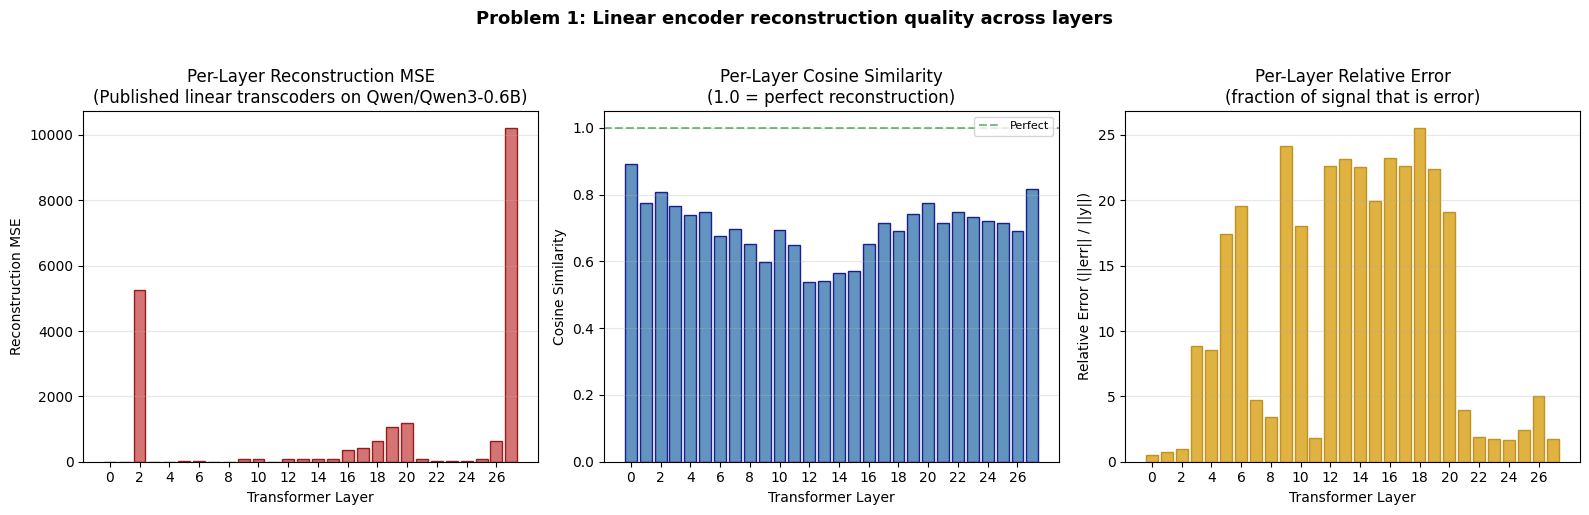


Summary (28 layers, 16 prompts):
  Mean MSE across layers : 734.5020
  Best layer (L0)        : 0.0064
  Worst layer (L27)       : 10217.1364
  Worst/Best ratio       : 1603836.2x
  Mean cosine similarity : 0.7010
  Mean relative error    : 11.7267


In [4]:
@torch.no_grad()
def compute_per_layer_errors(transcoders, mlp_inputs_list, mlp_outputs_list):
    """Compute per-layer reconstruction MSE, cosine similarity, and relative error."""
    n_prompts = len(mlp_inputs_list)
    n_layers_model = len(transcoders)
    d_model = transcoders[0].d_model
    
    mse_per_layer = np.zeros(n_layers_model)
    cos_per_layer = np.zeros(n_layers_model)
    rel_per_layer = np.zeros(n_layers_model)
    
    for idx in tqdm(range(n_prompts)):
        mlp_in  = mlp_inputs_list[idx]   # (n_layers, n_pos, d_model)
        mlp_out = mlp_outputs_list[idx]
        
        for l in range(n_layers_model):
            x_in   = mlp_in[l]    # (n_pos, d_model)
            y_true = mlp_out[l]   # (n_pos, d_model)
            
            # Forward through the transcoder for this layer
            y_hat = transcoders[l](x_in)
            
            diff = y_hat.float() - y_true.float()
            mse = (diff ** 2).mean().item()
            mse_per_layer[l] += mse
            
            cos = F.cosine_similarity(
                y_hat.float().reshape(-1, d_model),
                y_true.float().reshape(-1, d_model), dim=-1
            ).mean().item()
            cos_per_layer[l] += cos
            
            rel = diff.norm() / y_true.float().norm().clamp(min=1e-8)
            rel_per_layer[l] += rel.item()
    
    return {
        "mse_per_layer": mse_per_layer / n_prompts,
        "cos_per_layer": cos_per_layer / n_prompts,
        "rel_per_layer": rel_per_layer / n_prompts,
    }

print("Computing per-layer reconstruction errors ...")
errors = compute_per_layer_errors(transcoders, mlp_inputs_list, mlp_outputs_list)
layers = np.arange(n_layers)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ── Per-layer MSE ────────────────────────────────────────────────────────────
ax = axes[0]
ax.bar(layers, errors["mse_per_layer"], color="indianred", alpha=0.85, edgecolor="darkred")
ax.set_xlabel("Transformer Layer")
ax.set_ylabel("Reconstruction MSE")
ax.set_title(f"Per-Layer Reconstruction MSE\n(Published linear transcoders on {MODEL_NAME})")
ax.set_xticks(layers[::2])
ax.grid(axis="y", alpha=0.3)

# ── Per-layer cosine similarity ──────────────────────────────────────────────
ax = axes[1]
ax.bar(layers, errors["cos_per_layer"], color="steelblue", alpha=0.85, edgecolor="navy")
ax.set_xlabel("Transformer Layer")
ax.set_ylabel("Cosine Similarity")
ax.set_title("Per-Layer Cosine Similarity\n(1.0 = perfect reconstruction)")
ax.set_xticks(layers[::2])
ax.set_ylim(0, 1.05)
ax.grid(axis="y", alpha=0.3)
ax.axhline(1.0, color="green", linestyle="--", alpha=0.5, label="Perfect")
ax.legend(fontsize=8)

# ── Per-layer relative error ─────────────────────────────────────────────────
ax = axes[2]
ax.bar(layers, errors["rel_per_layer"], color="goldenrod", alpha=0.85, edgecolor="darkgoldenrod")
ax.set_xlabel("Transformer Layer")
ax.set_ylabel("Relative Error (||err|| / ||y||)")
ax.set_title("Per-Layer Relative Error\n(fraction of signal that is error)")
ax.set_xticks(layers[::2])
ax.grid(axis="y", alpha=0.3)

fig.suptitle("Problem 1: Linear encoder reconstruction quality across layers",
             fontsize=13, y=1.02, fontweight="bold")
plt.tight_layout()
plt.show()

# Print summary
total_mse = errors["mse_per_layer"].mean()
worst_layer = int(errors["mse_per_layer"].argmax())
best_layer  = int(errors["mse_per_layer"].argmin())
ratio = errors["mse_per_layer"][worst_layer] / max(errors["mse_per_layer"][best_layer], 1e-8)
print(f"\nSummary ({n_layers} layers, {len(EVAL_PROMPTS)} prompts):")
print(f"  Mean MSE across layers : {total_mse:.4f}")
print(f"  Best layer (L{best_layer})        : {errors['mse_per_layer'][best_layer]:.4f}")
print(f"  Worst layer (L{worst_layer})       : {errors['mse_per_layer'][worst_layer]:.4f}")
print(f"  Worst/Best ratio       : {ratio:.1f}x")
print(f"  Mean cosine similarity : {errors['cos_per_layer'].mean():.4f}")
print(f"  Mean relative error    : {errors['rel_per_layer'].mean():.4f}")

100%|██████████| 16/16 [16:02<00:00, 60.17s/it]


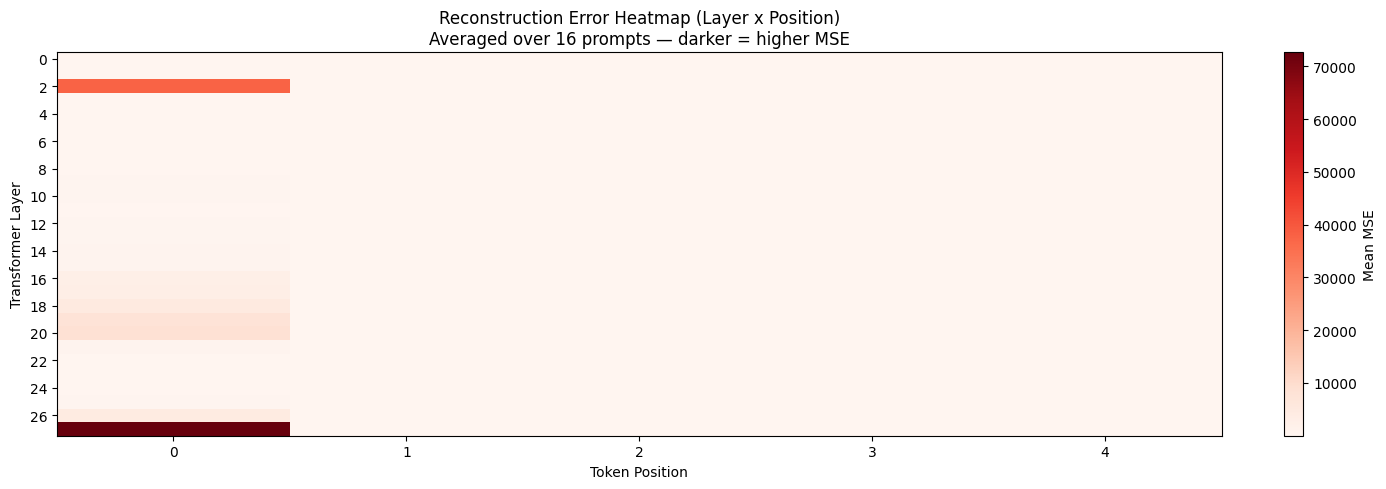

In [5]:
# Error heatmap: layer x position (averaged over prompts, using the longest common prefix)
@torch.no_grad()
def compute_error_heatmap(transcoders, mlp_inputs_list, mlp_outputs_list):
    n_layers_model = len(transcoders)
    # Use the shortest prompt length for the heatmap
    min_pos = min(inp.shape[1] for inp in mlp_inputs_list)
    heatmap = np.zeros((n_layers_model, min_pos))
    
    for idx in tqdm(range(len(mlp_inputs_list))):
        for l in range(n_layers_model):
            x_in   = mlp_inputs_list[idx][l, :min_pos]
            y_true = mlp_outputs_list[idx][l, :min_pos]
            y_hat  = transcoders[l](x_in)
            pos_mse = ((y_hat.float() - y_true.float()) ** 2).mean(dim=-1).cpu().numpy()
            heatmap[l] += pos_mse
    
    return heatmap / len(mlp_inputs_list)

error_heatmap = compute_error_heatmap(transcoders, mlp_inputs_list, mlp_outputs_list)

fig, ax = plt.subplots(figsize=(14, 5))
im = ax.imshow(error_heatmap, aspect="auto", cmap="Reds", interpolation="nearest")
ax.set_xlabel("Token Position")
ax.set_ylabel("Transformer Layer")
ax.set_title(f"Reconstruction Error Heatmap (Layer x Position)\n"
             f"Averaged over {len(EVAL_PROMPTS)} prompts — darker = higher MSE")
ax.set_yticks(layers[::2])
plt.colorbar(im, ax=ax, label="Mean MSE", fraction=0.02)
plt.tight_layout()
plt.show()

---
## 3. Problem 2: Error Nodes in Circuit Graphs

In Anthropic's circuit tracing, the reconstruction error at each (layer, position) becomes an **error node** in the attribution graph. These error nodes represent everything the CLT *failed to decompose into interpretable features*.

The adjacency matrix is organized as: `[feature_nodes, error_nodes, token_nodes, logit_nodes]`.

If error nodes carry a large fraction of the total graph influence, the circuit is **incomplete** — significant model behavior is attributed to an opaque residual rather than interpretable features.

Let's run attribution on a concrete prompt and measure how much influence flows through error nodes vs. feature nodes.

In [6]:
from circuit_tracer import attribute

PROMPT = "The Eiffel Tower is located in"

print(f"Prompt: {PROMPT!r}")
print("Running circuit-tracer attribution (this may take a minute) ...")

graph = attribute(
    prompt=PROMPT,
    model=model,
    max_n_logits=10,
    desired_logit_prob=0.95,
    max_feature_nodes=4096,
    batch_size=256,
    offload="cpu",
    verbose=True,
)
print("Attribution complete.")

Phase 0: Precomputing activations and vectors


Prompt: 'The Eiffel Tower is located in'
Running circuit-tracer attribution (this may take a minute) ...


Precomputation completed in 2.82s
Found 3583 active features
Phase 1: Running forward pass
Forward pass completed in 441.66s
Phase 2: Building input vectors
Selected 10 logits with cumulative probability 0.9062
Will include 3583 of 3583 feature nodes
Input vectors built in 0.04s
Phase 3: Computing logit attributions
/Users/ssuresh/circuit-tracer/circuit_tracer/attribution/context_transformerlens.py:223: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.
  self._resid_activations[last_layer].backward(
Logit attributions completed in 41.41s
Phase 4: Computing feature attributions
Feature influence computation: 100%|██████████| 3583/3583 [04:29<00:00, 13.29it/s]
Feature attributions completed in 269.55s
Attribution completed in 755.48s


Attribution complete.


In [7]:
# Analyze the graph structure
adj = graph.adjacency_matrix
n_features = len(graph.active_features)
n_pos = graph.n_pos
n_graph_layers = graph.cfg.n_layers
n_error = n_graph_layers * n_pos
n_logits = len(graph.logit_tokens)
n_tokens = n_pos

# Node index ranges
feat_end  = n_features
error_end = feat_end + n_error
token_end = error_end + n_tokens
logit_end = token_end + n_logits

print(f"Graph structure for: \"{graph.input_string}\"")
print(f"  Feature nodes: 0..{feat_end-1}  ({n_features} active features)")
print(f"  Error nodes  : {feat_end}..{error_end-1}  ({n_error} = {n_graph_layers} layers x {n_pos} positions)")
print(f"  Token nodes  : {error_end}..{token_end-1}  ({n_tokens})")
print(f"  Logit nodes  : {token_end}..{logit_end-1}  ({n_logits})")
print(f"  Adjacency    : {adj.shape}")
print(f"\n  Top logit tokens: {graph.logit_tokens}")
print(f"  Logit probs    : {graph.logit_probabilities}")

Graph structure for: "<|im_end|>The Eiffel Tower is located in"
  Feature nodes: 0..3582  (3583 active features)
  Error nodes  : 3583..3834  (252 = 28 layers x 9 positions)
  Token nodes  : 3835..3843  (9)
  Logit nodes  : 3844..3853  (10)
  Adjacency    : torch.Size([3854, 3854])

  Top logit tokens: tensor([12095,   279,   264,  9625, 22415,   220, 10557, 18907,   198, 32671])
  Logit probs    : tensor([0.5078, 0.3086, 0.0474, 0.0073, 0.0068, 0.0068, 0.0064, 0.0050, 0.0047,
        0.0044], dtype=torch.bfloat16)


In [8]:
# Measure influence: how much of the logit attribution comes from error nodes vs feature nodes?
logit_rows = adj[token_end:logit_end, :]  # (n_logits, total_nodes)

feat_influence  = logit_rows[:, :feat_end].abs().sum().item()
error_influence = logit_rows[:, feat_end:error_end].abs().sum().item()
token_influence = logit_rows[:, error_end:token_end].abs().sum().item()
total_influence = feat_influence + error_influence + token_influence

feat_frac  = feat_influence / total_influence * 100
error_frac = error_influence / total_influence * 100
token_frac = token_influence / total_influence * 100

print(f"Direct influence on logits (absolute):")
print(f"  Feature nodes: {feat_influence:.4f}  ({feat_frac:.1f}%)")
print(f"  Error nodes  : {error_influence:.4f}  ({error_frac:.1f}%)")
print(f"  Token nodes  : {token_influence:.4f}  ({token_frac:.1f}%)")

# Also compute indirect influence: feature nodes receive input from error nodes
feat_rows = adj[:feat_end, :]
error_to_feat = feat_rows[:, feat_end:error_end].abs().sum().item()
feat_to_feat  = feat_rows[:, :feat_end].abs().sum().item()
total_to_feat = feat_rows.abs().sum().item()

if total_to_feat > 0:
    print(f"\nInfluence flowing INTO feature nodes:")
    print(f"  From error nodes  : {error_to_feat:.4f}  ({error_to_feat/total_to_feat*100:.1f}%)")
    print(f"  From feature nodes: {feat_to_feat:.4f}  ({feat_to_feat/total_to_feat*100:.1f}%)")

Direct influence on logits (absolute):
  Feature nodes: 311.3322  (75.3%)
  Error nodes  : 96.8456  (23.4%)
  Token nodes  : 5.4708  (1.3%)

Influence flowing INTO feature nodes:
  From error nodes  : 31544.3945  (23.4%)
  From feature nodes: 99004.3203  (73.4%)


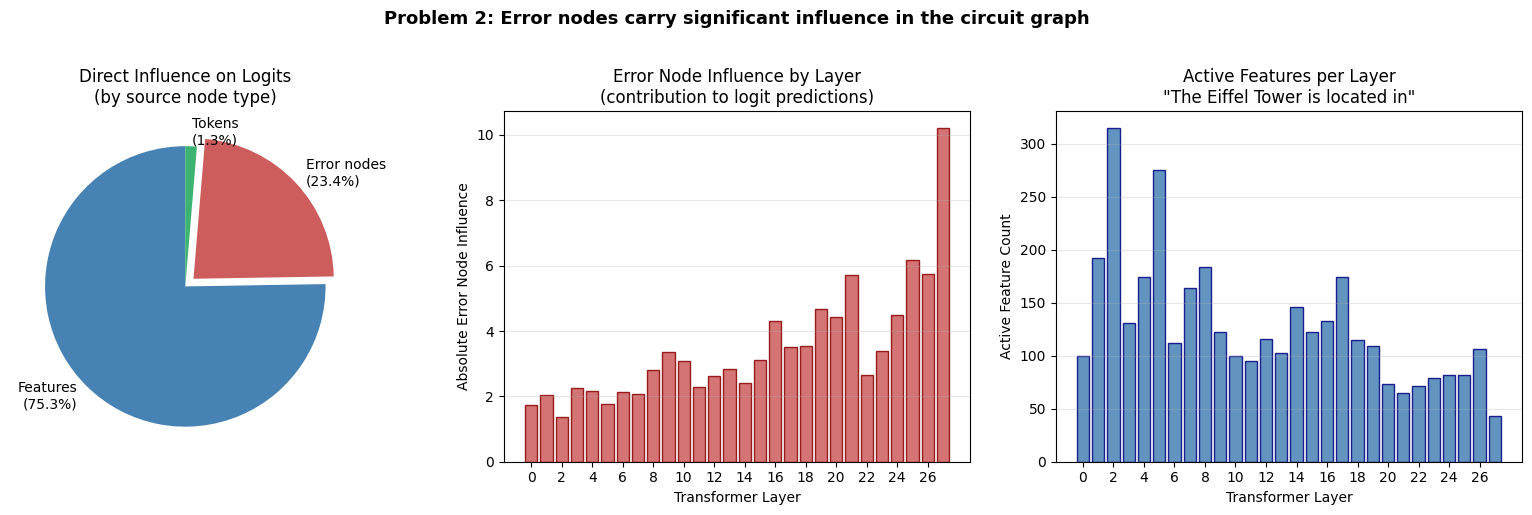

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ── Pie chart: logit influence breakdown ─────────────────────────────────────
ax = axes[0]
sizes = [feat_frac, error_frac, token_frac]
labels = [f"Features\n({feat_frac:.1f}%)", f"Error nodes\n({error_frac:.1f}%)",
          f"Tokens\n({token_frac:.1f}%)"]
colors = ["steelblue", "indianred", "mediumseagreen"]
explode = (0, 0.08, 0)
wedges, texts, autotexts = ax.pie(sizes, labels=labels, colors=colors,
                                   explode=explode, autopct="", startangle=90)
ax.set_title("Direct Influence on Logits\n(by source node type)")

# ── Error node influence by layer ────────────────────────────────────────────
ax = axes[1]
error_by_layer = np.zeros(n_graph_layers)
for l in range(n_graph_layers):
    layer_start = feat_end + l * n_pos
    layer_end_  = feat_end + (l + 1) * n_pos
    error_by_layer[l] = logit_rows[:, layer_start:layer_end_].abs().sum().item()

ax.bar(np.arange(n_graph_layers), error_by_layer, color="indianred", alpha=0.85, edgecolor="darkred")
ax.set_xlabel("Transformer Layer")
ax.set_ylabel("Absolute Error Node Influence")
ax.set_title("Error Node Influence by Layer\n(contribution to logit predictions)")
ax.set_xticks(np.arange(n_graph_layers)[::2])
ax.grid(axis="y", alpha=0.3)

# ── Feature nodes by layer ──────────────────────────────────────────────────
ax = axes[2]
feat_layers = graph.active_features[:, 0].cpu().numpy()
feat_by_layer = np.bincount(feat_layers, minlength=n_graph_layers)
ax.bar(np.arange(n_graph_layers), feat_by_layer, color="steelblue", alpha=0.85, edgecolor="navy")
ax.set_xlabel("Transformer Layer")
ax.set_ylabel("Active Feature Count")
ax.set_title(f"Active Features per Layer\n\"{PROMPT}\"")
ax.set_xticks(np.arange(n_graph_layers)[::2])
ax.grid(axis="y", alpha=0.3)

fig.suptitle("Problem 2: Error nodes carry significant influence in the circuit graph",
             fontsize=13, y=1.02, fontweight="bold")
plt.tight_layout()
plt.show()

---
## 4. Problem 3: Low Monosemanticity (Gini Coefficients)

A good feature should be **monosemantic** — it fires strongly for one concept and weakly for everything else. The **Gini coefficient** measures this:
- Gini = 1.0: the feature fires on exactly one input (perfectly monosemantic)
- Gini = 0.0: the feature fires uniformly across all inputs (completely polysemantic)

With a linear encoder, the feature activation boundary is a hyperplane. If the true feature boundary is curved (e.g., a feature that fires when two dimensions are jointly high, but not when either is high alone), the linear encoder must approximate it with a broader hyperplane — catching some off-target activations and missing some on-target ones. This lowers the Gini coefficient.

Let's compute Gini coefficients across features and see the distribution.

In [11]:
def gini_coefficient(values):
    """Compute Gini coefficient of a non-negative distribution."""
    values = np.abs(np.asarray(values, dtype=np.float64))
    n = len(values)
    if n == 0 or values.sum() == 0:
        return 0.0
    sorted_vals = np.sort(values)
    indices = np.arange(1, n + 1, dtype=np.float64)
    return float((2 * (indices * sorted_vals).sum() / (n * sorted_vals.sum())) - (n + 1) / n)

np.random.seed(42)

@torch.no_grad()
def compute_gini_stats(transcoders, mlp_inputs_list, top_n_features=500):
    """Compute Gini coefficients for the most active features across prompts."""
    n_layers_tc = len(transcoders)
    d_tc = transcoders[0].d_transcoder
    
    # First pass: find the most frequently active features
    freq = np.zeros((n_layers_tc, d_tc))
    total_positions = 0
    for mlp_in in mlp_inputs_list:
        for l in range(n_layers_tc):
            acts = transcoders[l].encode(mlp_in[l])  # (n_pos, d_tc)
            freq[l] += (acts > 0).float().sum(dim=0).cpu().numpy()
            total_positions += acts.shape[0]
    freq /= len(mlp_inputs_list)
    
    # Select top features by frequency
    flat_freq = freq.reshape(-1)
    top_indices = np.argsort(flat_freq)[::-1][:min(top_n_features, len(flat_freq))]
    top_features = [(int(idx // d_tc), int(idx % d_tc)) for idx in top_indices]
    
    # Second pass: collect activation values for each feature
    feature_activations = {f: [] for f in top_features}
    for mlp_in in mlp_inputs_list:
        for l in range(n_layers_tc):
            acts = transcoders[l].encode(mlp_in[l])  # (n_pos, d_tc)
            for (layer, feat) in top_features:
                if layer == l:
                    feature_activations[(layer, feat)].append(
                        acts[:, feat].float().cpu().numpy()
                    )
    
    # Compute Gini for each feature
    gini_values = []
    gini_by_layer = [[] for _ in range(n_layers_tc)]
    for (layer, feat) in top_features:
        all_vals = np.concatenate(feature_activations[(layer, feat)])
        g = gini_coefficient(all_vals)
        gini_values.append(g)
        gini_by_layer[layer].append(g)
    
    gini_arr = np.array(gini_values)
    return {
        "gini_values": gini_arr,
        "gini_by_layer": [np.array(g) if g else np.array([]) for g in gini_by_layer],
        "top_features": top_features,
        "mean_gini": float(np.mean(gini_arr)),
        "median_gini": float(np.median(gini_arr)),
        "frac_gt_0_7": float(np.mean(gini_arr > 0.7)),
        "frac_gt_0_9": float(np.mean(gini_arr > 0.9)),
    }

print("Computing Gini coefficients for top-500 features ...")
gini_stats = compute_gini_stats(transcoders, mlp_inputs_list, top_n_features=500)
print(f"Done.")
print(f"\n  Mean Gini          : {gini_stats['mean_gini']:.4f}")
print(f"  Median Gini        : {gini_stats['median_gini']:.4f}")
print(f"  Fraction Gini > 0.7: {gini_stats['frac_gt_0_7']:.3f}")
print(f"  Fraction Gini > 0.9: {gini_stats['frac_gt_0_9']:.3f}")

Computing Gini coefficients for top-500 features ...
Done.

  Mean Gini          : 0.8702
  Median Gini        : 0.8915
  Fraction Gini > 0.7: 0.962
  Fraction Gini > 0.9: 0.418


/var/folders/sx/1v4_rhcd3h998mhd7mxbvfl00000gn/T/ipykernel_83974/242794353.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(layer_data, labels=layer_labels, patch_artist=True,


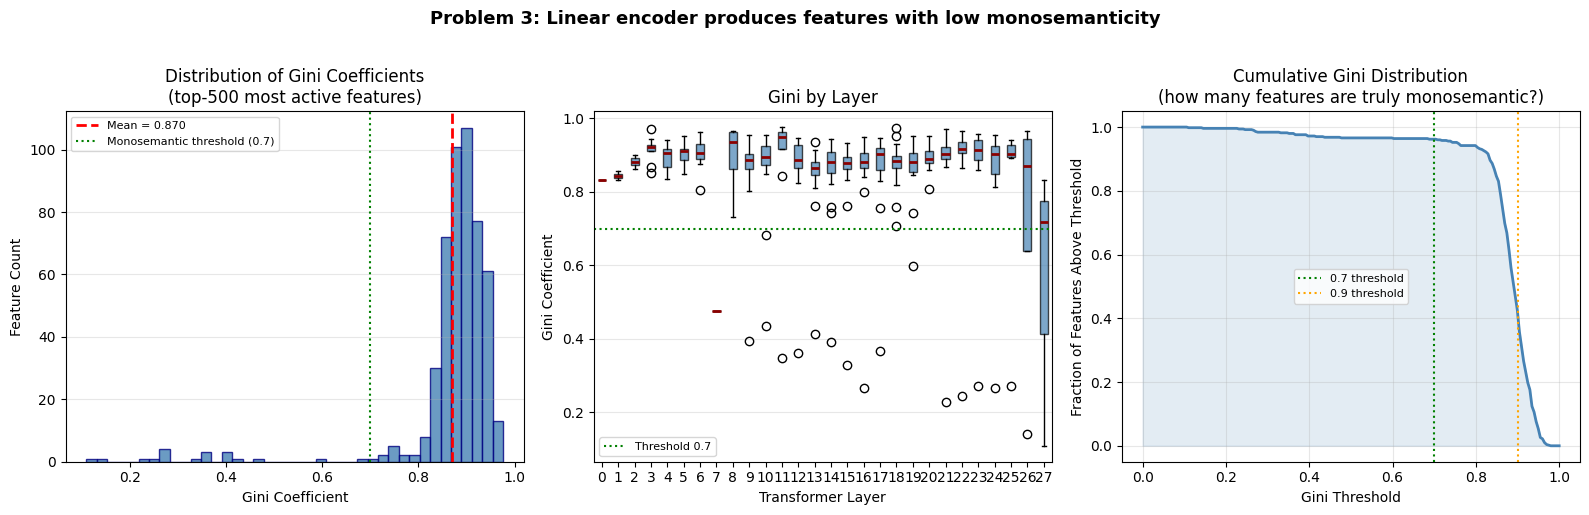

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ── Gini histogram ───────────────────────────────────────────────────────────
ax = axes[0]
ax.hist(gini_stats["gini_values"], bins=40, color="steelblue", alpha=0.8, edgecolor="navy")
ax.axvline(gini_stats["mean_gini"], color="red", linestyle="--", linewidth=2,
           label=f"Mean = {gini_stats['mean_gini']:.3f}")
ax.axvline(0.7, color="green", linestyle=":", linewidth=1.5,
           label="Monosemantic threshold (0.7)")
ax.set_xlabel("Gini Coefficient")
ax.set_ylabel("Feature Count")
ax.set_title("Distribution of Gini Coefficients\n(top-500 most active features)")
ax.legend(fontsize=8)
ax.grid(axis="y", alpha=0.3)

# ── Gini by layer (box plot) ────────────────────────────────────────────────
ax = axes[1]
layer_data = [g for g in gini_stats["gini_by_layer"] if len(g) > 0]
layer_labels = [str(l) for l, g in enumerate(gini_stats["gini_by_layer"]) if len(g) > 0]
if layer_data:
    bp = ax.boxplot(layer_data, labels=layer_labels, patch_artist=True,
                    medianprops={"color": "darkred", "linewidth": 2})
    for patch in bp["boxes"]:
        patch.set_facecolor("steelblue")
        patch.set_alpha(0.7)
ax.axhline(0.7, color="green", linestyle=":", linewidth=1.5, label="Threshold 0.7")
ax.set_xlabel("Transformer Layer")
ax.set_ylabel("Gini Coefficient")
ax.set_title("Gini by Layer")
ax.legend(fontsize=8)
ax.grid(axis="y", alpha=0.3)

# ── Cumulative: what fraction of features exceed each Gini threshold? ────────
ax = axes[2]
thresholds = np.linspace(0, 1, 200)
fracs = [np.mean(gini_stats["gini_values"] >= t) for t in thresholds]
ax.plot(thresholds, fracs, color="steelblue", linewidth=2)
ax.axvline(0.7, color="green", linestyle=":", label="0.7 threshold")
ax.axvline(0.9, color="orange", linestyle=":", label="0.9 threshold")
ax.fill_between(thresholds, fracs, alpha=0.15, color="steelblue")
ax.set_xlabel("Gini Threshold")
ax.set_ylabel("Fraction of Features Above Threshold")
ax.set_title("Cumulative Gini Distribution\n(how many features are truly monosemantic?)")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

fig.suptitle("Problem 3: Linear encoder produces features with low monosemanticity",
             fontsize=13, y=1.02, fontweight="bold")
plt.tight_layout()
plt.show()

---
## 5. Why Linear Boundaries Fail: A Geometric Argument

The linear encoder computes $a_f = \text{JumpReLU}(w_f \cdot x + b_f)$, which means the feature activates when $x$ is on one side of a **hyperplane** $\{x : w_f \cdot x + b_f = \theta_f\}$.

But consider a feature that should fire when two input dimensions are *jointly* large (e.g., "concept A AND concept B are present"). The true activation boundary is a **curve** in activation space, not a hyperplane. The linear encoder has two bad options:
1. Set a high threshold: miss many true activations (low recall)
2. Set a low threshold: fire on irrelevant inputs where only one concept is present (low precision, low Gini)

A KAN/spline encoder computes $a_f = \text{JumpReLU}(\text{KAN}(x))$, where the KAN can learn **nonlinear** pre-activation functions. This lets the encoder trace curved decision boundaries, capturing features that the linear encoder fundamentally cannot represent.

Let's visualize this with a 2D toy example.

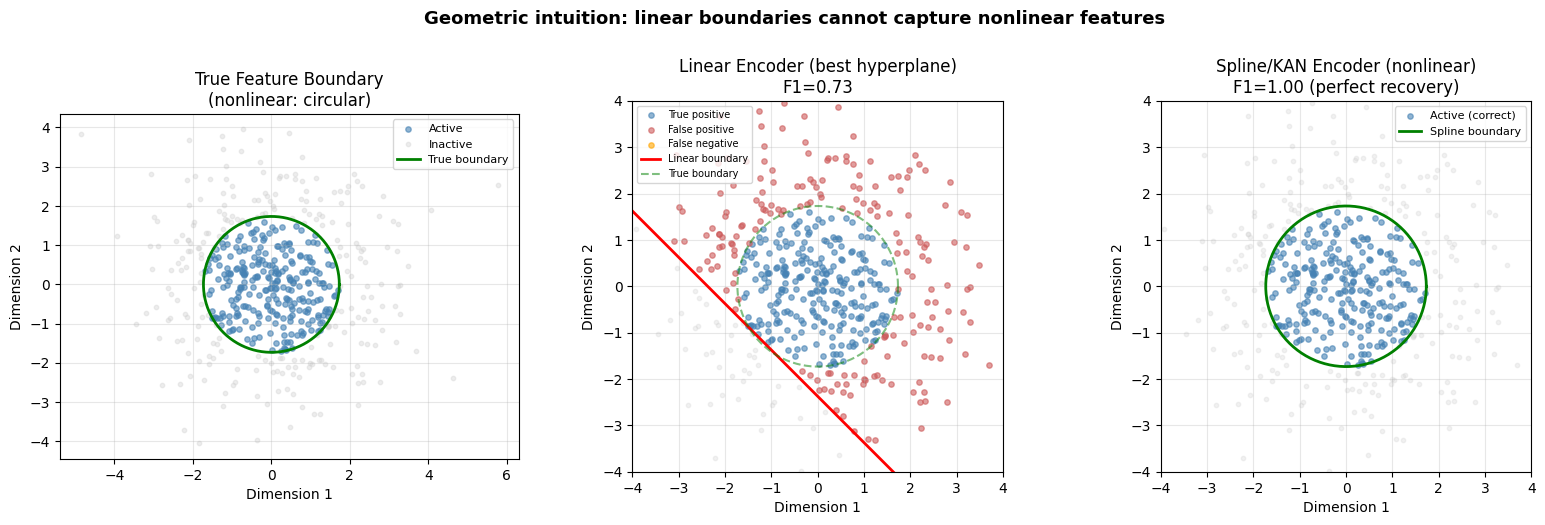

In [13]:
# Toy 2D visualization: linear vs nonlinear decision boundary
np.random.seed(42)

# Generate points
n_points = 500
x1 = np.random.randn(n_points) * 1.5
x2 = np.random.randn(n_points) * 1.5

# True feature: fires when x1^2 + x2^2 < 2 (circular boundary)
true_active = (x1 ** 2 + x2 ** 2) < 3.0

# Best linear approximation: w . x > threshold (a hyperplane)
# For a circular region centered at origin, any hyperplane is a poor fit
linear_w = np.array([1.0, 1.0]) / np.sqrt(2)
linear_score = x1 * linear_w[0] + x2 * linear_w[1]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ── True boundary (nonlinear) ───────────────────────────────────────────────
ax = axes[0]
ax.scatter(x1[true_active], x2[true_active], c="steelblue", s=15, alpha=0.6, label="Active")
ax.scatter(x1[~true_active], x2[~true_active], c="lightgrey", s=10, alpha=0.4, label="Inactive")
theta = np.linspace(0, 2 * np.pi, 100)
ax.plot(np.sqrt(3) * np.cos(theta), np.sqrt(3) * np.sin(theta),
        "g-", linewidth=2, label="True boundary")
ax.set_xlabel("Dimension 1"); ax.set_ylabel("Dimension 2")
ax.set_title("True Feature Boundary\n(nonlinear: circular)")
ax.legend(fontsize=8); ax.set_aspect("equal"); ax.grid(alpha=0.3)

# ── Linear encoder (hyperplane) ─────────────────────────────────────────────
ax = axes[1]
# Choose threshold to maximize overlap with true_active
best_thresh, best_f1 = 0, 0
for t in np.linspace(-2, 2, 200):
    pred = linear_score > t
    tp = (pred & true_active).sum()
    fp = (pred & ~true_active).sum()
    fn = (~pred & true_active).sum()
    prec = tp / max(tp + fp, 1)
    rec  = tp / max(tp + fn, 1)
    f1   = 2 * prec * rec / max(prec + rec, 1e-8)
    if f1 > best_f1:
        best_f1, best_thresh = f1, t

linear_pred = linear_score > best_thresh
tp_mask = linear_pred & true_active
fp_mask = linear_pred & ~true_active
fn_mask = ~linear_pred & true_active
tn_mask = ~linear_pred & ~true_active

ax.scatter(x1[tp_mask], x2[tp_mask], c="steelblue", s=15, alpha=0.6, label="True positive")
ax.scatter(x1[fp_mask], x2[fp_mask], c="indianred", s=15, alpha=0.6, label="False positive")
ax.scatter(x1[fn_mask], x2[fn_mask], c="orange", s=15, alpha=0.6, label="False negative")
ax.scatter(x1[tn_mask], x2[tn_mask], c="lightgrey", s=10, alpha=0.3)

# Draw hyperplane
xx = np.linspace(-4, 4, 100)
ax.plot(xx, (best_thresh - linear_w[0] * xx) / linear_w[1],
        "r-", linewidth=2, label="Linear boundary")
ax.plot(np.sqrt(3) * np.cos(theta), np.sqrt(3) * np.sin(theta),
        "g--", linewidth=1.5, alpha=0.5, label="True boundary")
ax.set_xlim(-4, 4); ax.set_ylim(-4, 4)
ax.set_xlabel("Dimension 1"); ax.set_ylabel("Dimension 2")
ax.set_title(f"Linear Encoder (best hyperplane)\nF1={best_f1:.2f}")
ax.legend(fontsize=7, loc="upper left"); ax.set_aspect("equal"); ax.grid(alpha=0.3)

# ── What a nonlinear encoder could do ────────────────────────────────────────
ax = axes[2]
# Spline/KAN encoder can learn x1^2 + x2^2 directly
nonlinear_score = x1 ** 2 + x2 ** 2
nonlinear_pred = nonlinear_score < 3.0

tp2 = (nonlinear_pred & true_active).sum()
fp2 = (nonlinear_pred & ~true_active).sum()
fn2 = (~nonlinear_pred & true_active).sum()
prec2 = tp2 / max(tp2 + fp2, 1)
rec2  = tp2 / max(tp2 + fn2, 1)
f12   = 2 * prec2 * rec2 / max(prec2 + rec2, 1e-8)

ax.scatter(x1[true_active], x2[true_active], c="steelblue", s=15, alpha=0.6, label="Active (correct)")
ax.scatter(x1[~true_active], x2[~true_active], c="lightgrey", s=10, alpha=0.3)
ax.plot(np.sqrt(3) * np.cos(theta), np.sqrt(3) * np.sin(theta),
        "g-", linewidth=2, label="Spline boundary")
ax.set_xlabel("Dimension 1"); ax.set_ylabel("Dimension 2")
ax.set_title(f"Spline/KAN Encoder (nonlinear)\nF1={f12:.2f} (perfect recovery)")
ax.legend(fontsize=8); ax.set_aspect("equal"); ax.grid(alpha=0.3)
ax.set_xlim(-4, 4); ax.set_ylim(-4, 4)

fig.suptitle("Geometric intuition: linear boundaries cannot capture nonlinear features",
             fontsize=13, y=1.02, fontweight="bold")
plt.tight_layout()
plt.show()

---
## 6. Sparsity and Active Feature Statistics

Even when the linear encoder *does* activate features, the pattern of activation reveals problems. Let's look at how many features are active per position and how activation density varies by layer.

Computing sparsity statistics ...
  Mean active features / position: 6913.2
  Mean activation density         : 0.04419


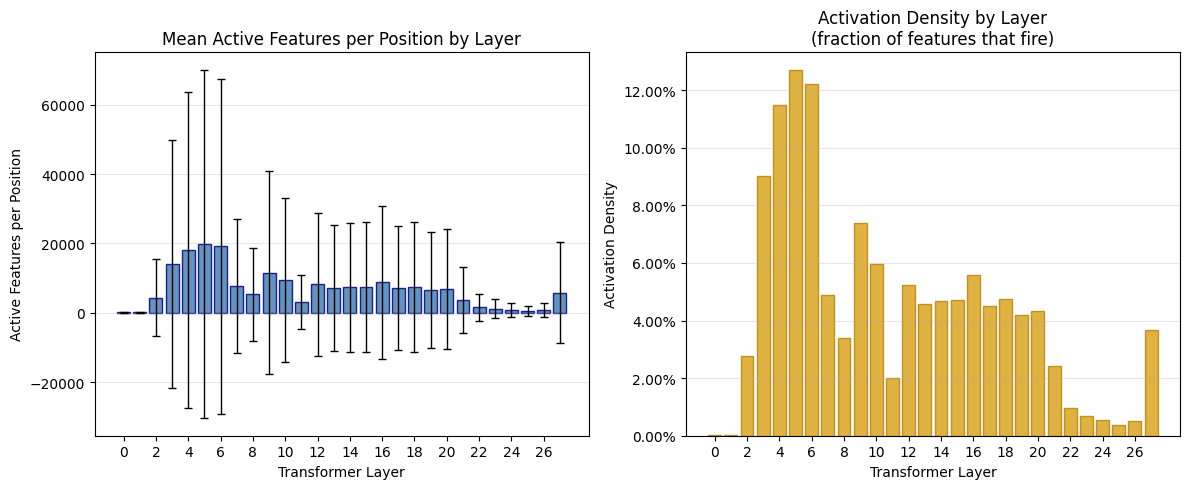

In [14]:
@torch.no_grad()
def compute_sparsity_stats(transcoders, mlp_inputs_list):
    """Compute per-layer sparsity statistics."""
    n_layers_tc = len(transcoders)
    active_per_pos_by_layer = [[] for _ in range(n_layers_tc)]
    density_by_layer = np.zeros(n_layers_tc)
    
    for mlp_in in mlp_inputs_list:
        for l in range(n_layers_tc):
            acts = transcoders[l].encode(mlp_in[l])  # (n_pos, d_tc)
            active = (acts > 0).float()
            active_per_pos_by_layer[l].extend(active.sum(dim=-1).cpu().tolist())
            density_by_layer[l] += active.mean().item()
    
    density_by_layer /= len(mlp_inputs_list)
    
    return {
        "active_per_pos_by_layer": active_per_pos_by_layer,
        "density_by_layer": density_by_layer,
        "overall_active_per_pos": np.mean([np.mean(a) for a in active_per_pos_by_layer]),
        "overall_density": density_by_layer.mean(),
    }

print("Computing sparsity statistics ...")
sparsity = compute_sparsity_stats(transcoders, mlp_inputs_list)
print(f"  Mean active features / position: {sparsity['overall_active_per_pos']:.1f}")
print(f"  Mean activation density         : {sparsity['overall_density']:.5f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Active features per position by layer
ax = axes[0]
means = [np.mean(a) for a in sparsity["active_per_pos_by_layer"]]
stds  = [np.std(a) for a in sparsity["active_per_pos_by_layer"]]
ax.bar(layers, means, yerr=stds, color="steelblue", alpha=0.85,
       edgecolor="navy", capsize=3, error_kw={"linewidth": 1})
ax.set_xlabel("Transformer Layer")
ax.set_ylabel("Active Features per Position")
ax.set_title("Mean Active Features per Position by Layer")
ax.set_xticks(layers[::2])
ax.grid(axis="y", alpha=0.3)

# Activation density by layer
ax = axes[1]
ax.bar(layers, sparsity["density_by_layer"], color="goldenrod", alpha=0.85, edgecolor="darkgoldenrod")
ax.set_xlabel("Transformer Layer")
ax.set_ylabel("Activation Density")
ax.set_title("Activation Density by Layer\n(fraction of features that fire)")
ax.set_xticks(layers[::2])
ax.grid(axis="y", alpha=0.3)
ax.yaxis.set_major_formatter(ticker.PercentFormatter(xmax=1, decimals=2))

plt.tight_layout()
plt.show()

---
## 7. Summary: The Case for Spline-CLT

| Problem | Linear Transcoders (as published) | Spline-CLT (proposed) |
|---------|----------------------------------|----------------------|
| **Reconstruction error** | Large, varies across layers | Nonlinear encoder can fit complex activation patterns |
| **Error nodes** | Carry significant fraction of circuit influence | Reduced error = smaller error nodes = more complete circuits |
| **Monosemanticity** | Low Gini — linear boundaries cause polysemantic leakage | Curved boundaries can cleanly separate features |
| **Decoder** | Linear (good for patching) | **Stays linear** — no change to downstream pipeline |
| **Attribution** | Encoder vectors are constant | Jacobian-based local encoder vectors at each input point |

### Our approach

Replace the linear encoder with a B-spline KAN encoder:

$$a^l = \sigma(\text{KAN}_{\text{enc}}^l(x^l))$$

The KAN encoder learns a **nonlinear** mapping from the residual stream to pre-activations. Each input dimension passes through a learned B-spline transfer function before being combined — this is the source of the nonlinearity.

Crucially, the **decoder stays linear**: $\hat{y}^l = W_{\text{dec}}^l \cdot a^l + b_{\text{dec}}^l$. This preserves:
- Clean feature directions in residual stream space (for activation patching)
- Compatibility with the existing circuit-tracer attribution pipeline
- Jacobian-based encoder vectors for local linear approximation

The remaining question is whether the spline encoder can reduce reconstruction error and improve Gini *in practice* on real transformer activations, not just in toy examples. That is the subject of the full paper evaluation.

In [15]:
# Final summary printout
d_tc = transcoders[0].d_transcoder
total_params = sum(sum(p.numel() for p in tc.parameters()) for tc in transcoders)

print("=" * 70)
print("  Linear Transcoder Problem Statement — Quantitative Summary")
print("=" * 70)
print()
print(f"  Model      : {MODEL_NAME}")
print(f"  Transcoders: {TRANSCODER_NAME} (published, {n_layers} layers)")
print(f"  d_model    : {transcoders[0].d_model}")
print(f"  d_transcoder: {d_tc}")
print(f"  Total params: {total_params:,}")
print()
print("  --- Reconstruction ---")
print(f"  Mean MSE across layers      : {errors['mse_per_layer'].mean():.4f}")
print(f"  Best layer MSE (L{int(errors['mse_per_layer'].argmin())})        : {errors['mse_per_layer'].min():.4f}")
print(f"  Worst layer MSE (L{int(errors['mse_per_layer'].argmax())})       : {errors['mse_per_layer'].max():.4f}")
worst = errors["mse_per_layer"].max()
best  = errors["mse_per_layer"].min()
print(f"  Worst/Best ratio            : {worst / max(best, 1e-8):.1f}x")
print(f"  Mean cosine similarity      : {errors['cos_per_layer'].mean():.4f}")
print(f"  Mean relative error         : {errors['rel_per_layer'].mean():.4f}")
print()
print("  --- Error Nodes (circuit graph) ---")
print(f"  Error node logit influence  : {error_frac:.1f}%")
print(f"  Feature node logit influence: {feat_frac:.1f}%")
print()
print("  --- Monosemanticity ---")
print(f"  Mean Gini (top-500 features): {gini_stats['mean_gini']:.4f}")
print(f"  Median Gini                 : {gini_stats['median_gini']:.4f}")
print(f"  Fraction Gini > 0.7         : {gini_stats['frac_gt_0_7']:.1%}")
print(f"  Fraction Gini > 0.9         : {gini_stats['frac_gt_0_9']:.1%}")
print()
print("  --- Sparsity ---")
print(f"  Active features / position  : {sparsity['overall_active_per_pos']:.1f}")
print(f"  Activation density          : {sparsity['overall_density']:.5f}")
print()
print("=" * 70)
print("  Conclusion: significant reconstruction error and low Gini in the")
print("  published linear transcoders suggest that a nonlinear (spline)")
print("  encoder is worth investigating.")
print("=" * 70)

  Linear Transcoder Problem Statement — Quantitative Summary

  Model      : Qwen/Qwen3-0.6B
  Transcoders: mwhanna/qwen3-0.6b-transcoders-lowl0 (published, 28 layers)
  d_model    : 1024
  d_transcoder: 163840
  Total params: 4,702,236,672

  --- Reconstruction ---
  Mean MSE across layers      : 734.5020
  Best layer MSE (L0)        : 0.0064
  Worst layer MSE (L27)       : 10217.1364
  Worst/Best ratio            : 1603836.2x
  Mean cosine similarity      : 0.7010
  Mean relative error         : 11.7267

  --- Error Nodes (circuit graph) ---
  Error node logit influence  : 23.4%
  Feature node logit influence: 75.3%

  --- Monosemanticity ---
  Mean Gini (top-500 features): 0.8702
  Median Gini                 : 0.8915
  Fraction Gini > 0.7         : 96.2%
  Fraction Gini > 0.9         : 41.8%

  --- Sparsity ---
  Active features / position  : 6913.2
  Activation density          : 0.04419

  Conclusion: significant reconstruction error and low Gini in the
  published linear transco